____
__Universidad de San Andrés__<br/>
__Visión Artificial__<br/>
__Sistema de Detección de Infracciones y Estimación de Velocidades__<br/>
__Martín Bianchi, Agustín Amblard y Federico Gutman__
____

### Importamos las librerías necesarias

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import yaml
import os
from src.aux import *
from src.visualization import *

### Cargamos las rutas y creamos los archivos necesarios

In [10]:
dataset_folder_name = Path("yolo-traffic-finetuning-2")
yaml_path = dataset_folder_name / "data.yaml"
yolo_runs_root = Path("yolo_runs")

images_train = dataset_folder_name / "train" / "images"
images_val   = dataset_folder_name / "valid" / "images"

trained_yolo_weights = str(yolo_runs_root / "DETRAC_YOLO" / "weights" / "best.pt")

### Mostramos imágenes de ejemplo del nuevo dataset

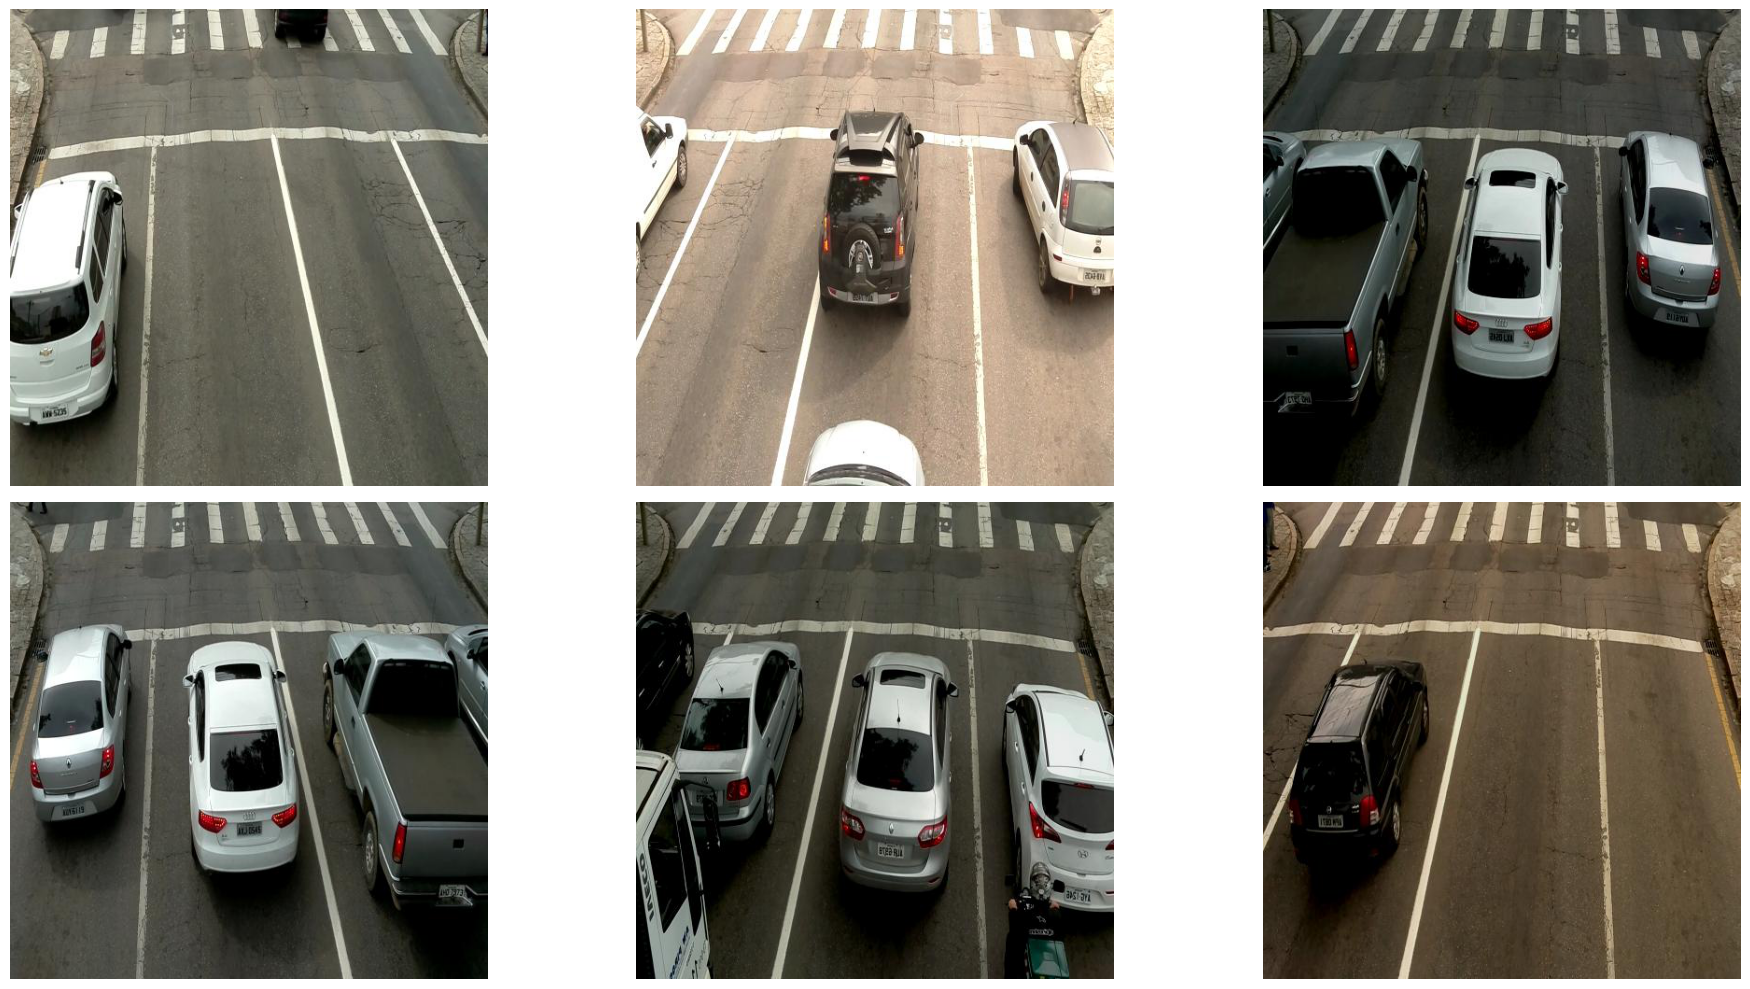

In [11]:
show_train_subsample(images_train, titles=False)

### Hacemos un finetuning del modelo usando el nuevo dataset

In [12]:
model = YOLO(trained_yolo_weights)

model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    freeze=10,
    lr0=0.001,
    optimizer='AdamW',
    project="yolo_finetune",
    name="finetuned_yolo",
    device='mps',
    plots=True
)

print("Entrenamiento finalizado. Revisa la carpeta 'yolo_finetune'.")

New https://pypi.org/project/ultralytics/8.3.235 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.205 🚀 Python-3.12.2 torch-2.8.0 MPS (Apple M1)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo-traffic-finetuning-2/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo_runs/DETRAC_YOLO/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=finetuned_yolo, nbs=64, 